# HW3 Image Classification — V4
## V4 修正與新增（相對於 V3）

| # | 改動 | 原因 |
|---|---|---|
| 1 | **StratifiedKFold 取代連續切塊** | V3 的 CV 切分在 sorted 檔名上連續切塊，各折類別分布嚴重失衡（bug） |
| 2 | **ResNet18（隨機初始化）取代 VGG-like CNN** | residual + GAP，天花板更高、FC 參數大減（作業允許架構、不允許 pretrained weights） |
| 3 | **TTA 改為確定性溫和版**（原圖 + 水平翻轉），**softmax 後平均** | V3 用訓練級增強做 TTA 太激進；logits 直接累加會被尺度大的模型主導 |
| 4 | **MixUp / CutMix 輪替 + 保留乾淨 batch**（40% / 40% / 20%） | V3 100% MixUp，模型從未見過乾淨圖 + hard label，收斂偏慢 |
| 5 | **AMP 混合精度** | P100 FP16 吞吐約 2×，省下的時間拿去多跑 epochs |
| 6 | **移除 Early Stopping，跑滿 cosine 週期** | patience 會在 LR 降完前砍掉訓練，錯過後期跳升 |
| 7 | **Resize 保持長寬比 + Crop** | `Resize((128,128))` 會壓縮比例失真 |

保留 V3 的：5-fold CV + Ensemble、Label Smoothing、LR Warmup + Cosine、Gradient Accumulation、RandomErasing、斷點續訓、history JSON + 訓練曲線。

# Check GPU

In [1]:
!nvidia-smi

Wed Jul  8 15:56:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
print(torch.cuda.is_available())

True


# Data Path

In [3]:
import os
DATA_DIR = "/kaggle/input/competitions/ml2023spring-hw3"
print(os.listdir(DATA_DIR))

['valid', 'test', 'train']


In [5]:
_exp_name = "v4_resnet18"

# Import Packages

In [6]:
import numpy as np
import pandas as pd
import torch
import os
import json
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision.models import resnet18
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
import random
import math

In [7]:
myseed = 6666
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(myseed)
random.seed(myseed)
torch.manual_seed(myseed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(myseed)

# Transforms

**V4 改動 7：保持長寬比**
- `Resize(146)` 只縮短邊（保持比例）→ 再 crop 成 128×128
- train 用 `RandomResizedCrop`（隨機尺度 + 位置，本身就是很強的增強）
- test 用 `CenterCrop`（確定性）

**TTA（V4 改動 3）：** 只做「原圖」和「必定水平翻轉」兩個確定性版本，不再用訓練級的隨機增強。

In [8]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── 測試 / 驗證用（確定性）──
test_tfm = transforms.Compose([
    transforms.Resize(146),              # 短邊縮到 146，保持長寬比
    transforms.CenterCrop(128),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── 訓練用（Q1：6+ 種增強）──
train_tfm = transforms.Compose([
    # 增強1：隨機尺度裁切（取原圖 50%~100% 的區域，隨機位置，再縮到 128）
    transforms.RandomResizedCrop(128, scale=(0.5, 1.0), ratio=(0.75, 1.333)),
    transforms.RandomHorizontalFlip(p=0.5),     # 增強2：水平翻轉
    transforms.RandomRotation(degrees=15),      # 增強3：旋轉（收斂到 ±15 度，食物照少有大角度）
    transforms.ColorJitter(                     # 增強4：顏色抖動
        brightness=0.3, contrast=0.3,
        saturation=0.3, hue=0.1
    ),
    transforms.RandomGrayscale(p=0.1),          # 增強5：灰階
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    # 增強6：隨機遮擋（必須在 ToTensor 之後）
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
])

# ── TTA 用（V4：確定性、溫和）──
tta_tfms = [
    test_tfm,                                   # 版本 1：原圖
    transforms.Compose([                        # 版本 2：必定水平翻轉
        transforms.Resize(146),
        transforms.CenterCrop(128),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]),
]

# Dataset

In [9]:
class FoodDataset(Dataset):
    def __init__(self, path, tfm=test_tfm, files=None):
        super(FoodDataset).__init__()
        self.path = path
        self.files = sorted([
            os.path.join(path, x)
            for x in os.listdir(path)
            if x.endswith(".jpg")
        ])
        if files is not None:
            self.files = files
        self.transform = tfm

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        im = Image.open(fname).convert("RGB")
        im = self.transform(im)
        try:
            label = int(os.path.basename(fname).split("_")[0])
        except:
            label = -1
        return im, label

# Model（V4 改動 2：ResNet18 from scratch）

- `weights=None` → **隨機初始化**，符合作業「不可用 pretrained weights」的規定
- residual connection 讓 18 層網路可以順利訓練
- 內建 Global Average Pooling → FC 只有 512×11 個參數（V3 的 FC 有 200 萬+）

**t-SNE 的 mid / top layer 對應（Q2 用）：**
- mid layer = `layer2` 輸出（[B, 128, 16, 16]，低中階特徵）
- top layer = `layer4` 輸出（[B, 512, 4, 4]，GAP 前的高階語義特徵）

In [10]:
def get_model():
    # weights=None：從零開始訓練（作業不允許 pretrained weights）
    return resnet18(weights=None, num_classes=11)

# 確認參數量
_m = get_model()
n_params = sum(p.numel() for p in _m.parameters())
print(f"ResNet18 參數量：{n_params/1e6:.2f} M")
del _m

ResNet18 參數量：11.18 M


# Configurations

**V4 改動 5 & 6：**
- 開 AMP（`torch.cuda.amp`），P100 上約 2× 提速
- **移除 early stopping**：跑滿整個 cosine 週期（LR 降到底時 valid acc 常會再跳一波）
- 斷點續訓仍保留，Kaggle session 斷線可接續

**時間預算提醒：** 5 折 × 100 epochs 在 P100 上可能超過單一 session 上限。
可以用 `TRAIN_FOLDS` 控制這個 session 要跑哪幾折，分多個 session 完成（checkpoint 會自動接續）。

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"使用裝置：{device}")

# ── Hyperparameters ──
batch_size         = 64    # ResNet18@128 + AMP 在 P100(16GB) 上輕鬆放得下
accumulation_steps = 4     # 等效 batch = 64 × 4 = 256
n_epochs           = 100   # 跑滿 cosine 週期，不做 early stopping
warmup_epochs      = 5
lr_max             = 5e-4
weight_decay       = 1e-4
n_folds            = 5

# 這個 session 要訓練哪幾折（斷點續訓會自動接續未完成的折）
TRAIN_FOLDS = [0, 1, 2, 3, 4]

# ── Label Smoothing（沿用 V3）──
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# ── AMP ──
use_amp = (device == "cuda")

print(f"等效 batch size：{batch_size * accumulation_steps}")
print(f"AMP：{use_amp}")

使用裝置：cuda
等效 batch size：256
AMP：True


# LR Warmup + Cosine Annealing（同 V2/V3）

In [21]:
def get_lr(epoch, warmup_epochs, n_epochs, lr_max, eta_min=1e-6):
    if epoch < warmup_epochs:
        return lr_max * (epoch + 1) / warmup_epochs
    else:
        progress = (epoch - warmup_epochs) / (n_epochs - warmup_epochs)
        return eta_min + 0.5 * (lr_max - eta_min) * (1 + math.cos(math.pi * progress))

# MixUp / CutMix 輪替（V4 改動 4）

每個 batch 擲一次骰子：
```
40% → MixUp   （兩張圖線性混合）
40% → CutMix  （把圖 B 的一塊矩形貼到圖 A 上，λ = 面積比）
20% → 乾淨 batch（原圖 + hard label）
```
CutMix 對影像分類通常比 MixUp 更有效（保留局部真實紋理）；
保留乾淨 batch 讓模型也看得到「真實的圖長什麼樣」，收斂更穩。

In [22]:
def mixup_data(imgs, labels, alpha=0.2):
    lam   = np.random.beta(alpha, alpha)
    index = torch.randperm(imgs.size(0), device=imgs.device)
    mixed = lam * imgs + (1 - lam) * imgs[index]
    return mixed, labels, labels[index], lam

def cutmix_data(imgs, labels, alpha=1.0):
    lam   = np.random.beta(alpha, alpha)
    index = torch.randperm(imgs.size(0), device=imgs.device)

    H, W = imgs.size(2), imgs.size(3)
    cut_ratio = math.sqrt(1.0 - lam)
    cut_h, cut_w = int(H * cut_ratio), int(W * cut_ratio)
    cy, cx = np.random.randint(H), np.random.randint(W)
    y1, y2 = np.clip(cy - cut_h // 2, 0, H), np.clip(cy + cut_h // 2, 0, H)
    x1, x2 = np.clip(cx - cut_w // 2, 0, W), np.clip(cx + cut_w // 2, 0, W)

    imgs = imgs.clone()
    imgs[:, :, y1:y2, x1:x2] = imgs[index, :, y1:y2, x1:x2]
    # 依實際貼上面積修正 lambda
    lam = 1 - ((y2 - y1) * (x2 - x1) / (H * W))
    return imgs, labels, labels[index], lam

def mix_criterion(criterion, logits, labels_a, labels_b, lam):
    return lam * criterion(logits, labels_a) + (1 - lam) * criterion(logits, labels_b)

# CV 資料切分（V4 改動 1：StratifiedKFold）

**V3 的 bug：** 檔名 `{label}_{id}.jpg` 經 `sorted()` 後是按類別排序的，
連續切塊會讓某折的驗證集只剩 2~3 個類別、訓練集缺少這些類別。

**V4 修法：** 用 `StratifiedKFold(shuffle=True)`，每折的類別比例都與整體一致。

In [23]:
from sklearn.model_selection import StratifiedKFold

all_train_files = (
    sorted([os.path.join(DATA_DIR, "train", x)
            for x in os.listdir(os.path.join(DATA_DIR, "train"))
            if x.endswith(".jpg")])
  + sorted([os.path.join(DATA_DIR, "valid", x)
            for x in os.listdir(os.path.join(DATA_DIR, "valid"))
            if x.endswith(".jpg")])
)
all_labels = [int(os.path.basename(f).split("_")[0]) for f in all_train_files]
print(f"合併後總筆數：{len(all_train_files)}")

skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=myseed)
fold_splits = list(skf.split(all_train_files, all_labels))  # [(train_idx, valid_idx), ...]

# ── 驗證各折類別分布（V3 在這裡會嚴重失衡）──
from collections import Counter
for k, (tr_idx, va_idx) in enumerate(fold_splits):
    va_labels = [all_labels[i] for i in va_idx]
    cnt = Counter(va_labels)
    print(f"Fold {k+1} valid 各類別數量：", dict(sorted(cnt.items())))

合併後總筆數：13643
Fold 1 valid 各類別數量： {0: 272, 1: 411, 2: 119, 3: 364, 4: 76, 5: 119, 6: 238, 7: 411, 8: 191, 9: 282, 10: 246}
Fold 2 valid 各類別數量： {0: 272, 1: 411, 2: 119, 3: 364, 4: 76, 5: 119, 6: 238, 7: 411, 8: 191, 9: 282, 10: 246}
Fold 3 valid 各類別數量： {0: 271, 1: 411, 2: 120, 3: 364, 4: 76, 5: 119, 6: 238, 7: 411, 8: 191, 9: 282, 10: 246}
Fold 4 valid 各類別數量： {0: 271, 1: 411, 2: 120, 3: 364, 4: 76, 5: 119, 6: 238, 7: 411, 8: 190, 9: 282, 10: 246}
Fold 5 valid 各類別數量： {0: 271, 1: 411, 2: 119, 3: 364, 4: 76, 5: 120, 6: 237, 7: 412, 8: 190, 9: 282, 10: 246}


# Training Function（AMP + Mix 增強 + Resume，無 Early Stopping）

In [24]:
def train_one_fold(fold_k, train_files, valid_files, resume_ckpt=None):
    """
    訓練單一折，跑滿 n_epochs（無 early stopping）。
    V4：AMP 混合精度 + MixUp/CutMix 輪替。
    """
    print(f"\n{'='*50}")
    print(f"Fold {fold_k+1}/{n_folds}  訓練:{len(train_files)}  驗證:{len(valid_files)}")
    print(f"{'='*50}")

    train_set = FoodDataset(DATA_DIR+"/train", tfm=train_tfm, files=train_files)
    valid_set = FoodDataset(DATA_DIR+"/train", tfm=test_tfm,  files=valid_files)
    train_loader = DataLoader(train_set, batch_size=batch_size,
                              shuffle=True,  num_workers=2,
                              persistent_workers=True, pin_memory=True)
    valid_loader = DataLoader(valid_set, batch_size=batch_size,
                              shuffle=False, num_workers=2,
                              persistent_workers=True, pin_memory=True)

    model     = get_model().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr_max, weight_decay=weight_decay)
    # 建 scaler
    scaler_f = torch.amp.GradScaler('cuda', enabled=use_amp)

    start_epoch = 0
    best_acc    = 0

    history = {
        "fold": fold_k,
        "train_loss": [], "train_acc": [],
        "valid_loss": [], "valid_acc": [],
        "lr": [], "best_epoch": -1, "best_acc": 0,
    }

    if resume_ckpt is not None:
        model.load_state_dict(resume_ckpt["model"])
        optimizer.load_state_dict(resume_ckpt["optimizer"])
        scaler_f.load_state_dict(resume_ckpt["scaler"])
        start_epoch = resume_ckpt["epoch"] + 1
        best_acc    = resume_ckpt["best_acc"]
        history     = resume_ckpt.get("history", history)
        print(f"從 epoch {start_epoch+1} 繼續，目前最佳 acc = {best_acc:.5f}")

    for epoch in range(start_epoch, n_epochs):
        lr = get_lr(epoch, warmup_epochs, n_epochs, lr_max)
        for pg in optimizer.param_groups:
            pg["lr"] = lr

        # ────────── Training ──────────
        model.train()
        tr_loss, tr_acc = [], []
        optimizer.zero_grad()

        for i, (imgs, labels) in enumerate(tqdm(train_loader, desc=f"Fold{fold_k+1} Ep{epoch+1} Train")):
            imgs, labels = imgs.to(device), labels.to(device)

            # ── MixUp / CutMix / 乾淨 batch 輪替（40/40/20）──
            r = np.random.rand()
            if r < 0.4:
                imgs, la, lb, lam = mixup_data(imgs, labels, alpha=0.2)
            elif r < 0.8:
                imgs, la, lb, lam = cutmix_data(imgs, labels, alpha=1.0)
            else:
                la, lb, lam = labels, labels, 1.0

            # ── AMP forward ──
            with torch.amp.autocast('cuda', enabled=use_amp):
                logits = model(imgs)
                loss   = mix_criterion(criterion, logits, la, lb, lam)
                loss   = loss / accumulation_steps

            scaler_f.scale(loss).backward()

            if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
                scaler_f.unscale_(optimizer)  # unscale 後才能做 grad clipping
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=10)
                scaler_f.step(optimizer)
                scaler_f.update()
                optimizer.zero_grad()

            # 注意：mix batch 的 acc 只對 labels_a 算，僅供趨勢參考
            acc = (logits.argmax(dim=-1) == la).float().mean()
            tr_loss.append(loss.item() * accumulation_steps)
            tr_acc.append(acc.item())

        ep_tr_loss = sum(tr_loss) / len(tr_loss)
        ep_tr_acc  = sum(tr_acc)  / len(tr_acc)
        print(f"[ Train | {epoch+1:03d}/{n_epochs:03d} ] loss={ep_tr_loss:.4f} acc={ep_tr_acc:.4f} lr={lr:.2e}")

        # ────────── Validation ──────────
        model.eval()
        va_loss, va_acc = [], []
        for imgs, labels in tqdm(valid_loader, desc=f"Fold{fold_k+1} Ep{epoch+1} Valid"):
            imgs, labels = imgs.to(device), labels.to(device)
            with torch.no_grad(), torch.amp.autocast('cuda', enabled=use_amp):
                logits = model(imgs)
            loss = criterion(logits, labels)
            acc  = (logits.argmax(dim=-1) == labels).float().mean()
            va_loss.append(loss.item())
            va_acc.append(acc.item())

        ep_va_loss = sum(va_loss) / len(va_loss)
        ep_va_acc  = sum(va_acc)  / len(va_acc)
        print(f"[ Valid | {epoch+1:03d}/{n_epochs:03d} ] loss={ep_va_loss:.4f} acc={ep_va_acc:.4f}")

        # ── 紀錄 ──
        history["train_loss"].append(round(ep_tr_loss, 5))
        history["train_acc"].append(round(ep_tr_acc, 5))
        history["valid_loss"].append(round(ep_va_loss, 5))
        history["valid_acc"].append(round(ep_va_acc, 5))
        history["lr"].append(round(lr, 8))

        with open(f"{_exp_name}_fold{fold_k}_log.txt", "a") as f:
            msg = (f"[{epoch+1:03d}] train_loss={ep_tr_loss:.4f} train_acc={ep_tr_acc:.4f} "
                   f"valid_loss={ep_va_loss:.4f} valid_acc={ep_va_acc:.4f} lr={lr:.2e}")
            print(msg + (" -> best" if ep_va_acc > best_acc else ""), file=f)

        # ── 儲存最佳模型（無 early stopping，但仍存 best）──
        if ep_va_acc > best_acc:
            print(f"  ✓ Best model at epoch {epoch+1}, saving...")
            torch.save(model.state_dict(), f"{_exp_name}_fold{fold_k}.ckpt")
            best_acc              = ep_va_acc
            history["best_acc"]   = round(best_acc, 5)
            history["best_epoch"] = epoch + 1

        # ── 每個 epoch 存 checkpoint（斷線可繼續）──
        torch.save({
            "fold": fold_k, "epoch": epoch,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scaler": scaler_f.state_dict(),
            "best_acc": best_acc, "history": history,
        }, f"{_exp_name}_fold{fold_k}_checkpoint.pt")

        with open(f"{_exp_name}_fold{fold_k}_history.json", "w") as f:
            json.dump(history, f, indent=2)

    print(f"Fold {fold_k+1} 完成！最佳 valid acc = {best_acc:.5f}（epoch {history['best_epoch']}）")
    return best_acc, history

# Run Cross Validation

In [25]:
fold_accs     = []
all_histories = []

for k in range(n_folds):
    tr_idx, va_idx = fold_splits[k]
    train_files = [all_train_files[i] for i in tr_idx]
    valid_files = [all_train_files[i] for i in va_idx]

    ckpt_path        = f"{_exp_name}_fold{k}.ckpt"
    resume_ckpt_path = f"{_exp_name}_fold{k}_checkpoint.pt"
    hist_path        = f"{_exp_name}_fold{k}_history.json"

    # 不在本 session 訓練清單中 → 跳過
    if k not in TRAIN_FOLDS:
        print(f"Fold {k+1} 不在 TRAIN_FOLDS，跳過")
        fold_accs.append(None)
        if os.path.exists(hist_path):
            with open(hist_path) as f:
                all_histories.append(json.load(f))
        continue

    # 已跑完整 n_epochs → 跳過（checkpoint 的 epoch 到達 n_epochs-1 視為完成）
    if os.path.exists(resume_ckpt_path):
        _ck = torch.load(resume_ckpt_path, map_location="cpu")
        if _ck["epoch"] >= n_epochs - 1:
            print(f"Fold {k+1} 已完成，跳過")
            fold_accs.append(_ck["best_acc"])
            all_histories.append(_ck.get("history", {}))
            continue
        print(f"Fold {k+1} 偵測到中斷點，從 epoch {_ck['epoch']+2} 繼續...")
        resume_ckpt = _ck
    else:
        resume_ckpt = None

    acc, history = train_one_fold(k, train_files, valid_files, resume_ckpt)
    fold_accs.append(acc)
    all_histories.append(history)

print(f"\n{'='*50}")
print("Cross Validation 結果：")
for k, acc in enumerate(fold_accs):
    print(f"  Fold {k+1}: {acc:.5f}" if acc is not None else f"  Fold {k+1}: 已跳過")
done = [a for a in fold_accs if a is not None]
if done:
    print(f"  平均 valid acc: {sum(done)/len(done):.5f}")

Fold 1 偵測到中斷點，從 epoch 2 繼續...

Fold 1/5  訓練:10914  驗證:2729
從 epoch 2 繼續，目前最佳 acc = 0.30709


Fold1 Ep2 Train:   0%|          | 0/171 [00:00<?, ?it/s]

[ Train | 002/100 ] loss=2.1501 acc=0.2346 lr=2.00e-04


Fold1 Ep2 Valid:   0%|          | 0/43 [00:00<?, ?it/s]

[ Valid | 002/100 ] loss=1.9740 acc=0.3489
  ✓ Best model at epoch 2, saving...


...

[ Valid | 099/100 ] loss=0.9724 acc=0.8037


Fold5 Ep100 Train:   0%|          | 0/171 [00:00<?, ?it/s]

[ Train | 100/100 ] loss=1.2226 acc=0.6080 lr=1.14e-06


Fold5 Ep100 Valid:   0%|          | 0/43 [00:00<?, ?it/s]

[ Valid | 100/100 ] loss=0.9774 acc=0.8061
Fold 5 完成！最佳 valid acc = 0.80974（epoch 93）

Cross Validation 結果：
  Fold 1: 0.80540
  Fold 2: 0.80165
  Fold 3: 0.80869
  Fold 4: 0.80276
  Fold 5: 0.80974
  平均 valid acc: 0.80565


# 訓練歷史視覺化

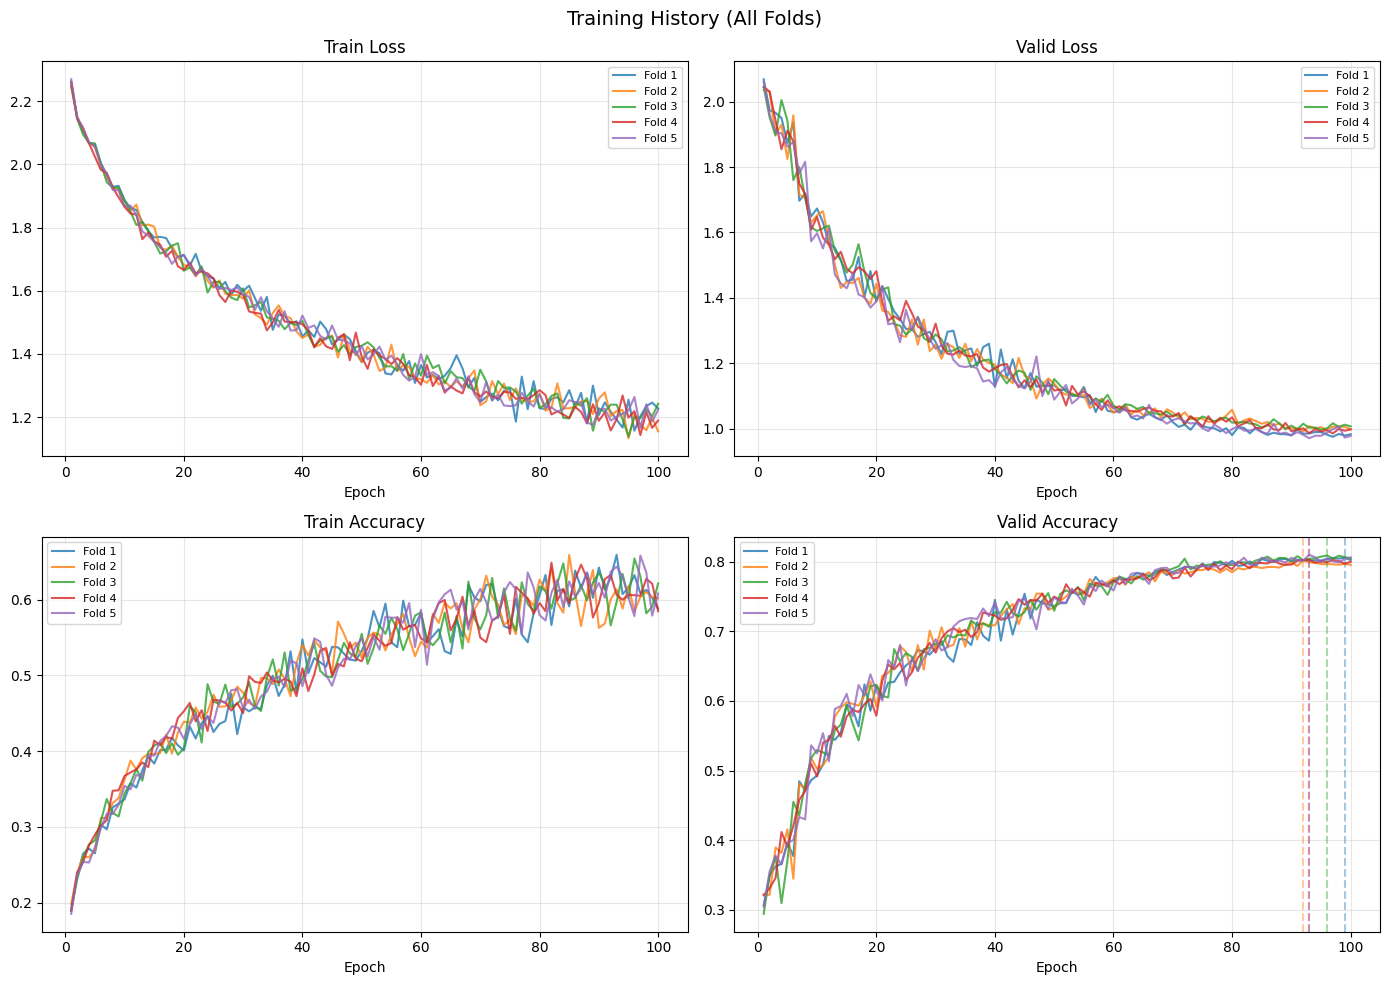


各折訓練摘要：
  Fold  Best Epoch  Best Valid Acc
------------------------------------
     1          99         0.80540
     2          92         0.80165
     3          96         0.80869
     4          93         0.80276
     5          93         0.80974


In [26]:
import matplotlib.pyplot as plt

def plot_history(histories):
    histories = [h for h in histories if h.get("train_loss")]
    if not histories:
        print("尚無歷史可畫")
        return
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Training History (All Folds)", fontsize=14)
    colors = plt.cm.tab10(range(len(histories)))

    for hist, color in zip(histories, colors):
        fold_label = f"Fold {hist['fold']+1}"
        epochs = range(1, len(hist["train_loss"]) + 1)
        axes[0, 0].plot(epochs, hist["train_loss"], color=color, label=fold_label, alpha=0.8)
        axes[0, 1].plot(epochs, hist["valid_loss"], color=color, label=fold_label, alpha=0.8)
        axes[1, 0].plot(epochs, hist["train_acc"],  color=color, label=fold_label, alpha=0.8)
        axes[1, 1].plot(epochs, hist["valid_acc"],  color=color, label=fold_label, alpha=0.8)
        best_ep = hist.get("best_epoch", -1)
        if 0 < best_ep <= len(hist["valid_acc"]):
            axes[1, 1].axvline(x=best_ep, color=color, linestyle="--", alpha=0.4)

    for ax, title in zip(axes.flat, ["Train Loss", "Valid Loss", "Train Accuracy", "Valid Accuracy"]):
        ax.set_title(title); ax.set_xlabel("Epoch")
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{_exp_name}_training_history.png", dpi=150)
    plt.show()

plot_history(all_histories)

print("\n各折訓練摘要：")
print(f"  Fold  Best Epoch  Best Valid Acc")
print("-" * 36)
for hist in all_histories:
    if hist.get("best_epoch", -1) > 0:
        print(f"  {hist['fold']+1:>4}  {hist['best_epoch']:>10}  {hist['best_acc']:>14.5f}")

# Testing：Ensemble + 確定性 TTA（V4 改動 3）

- 每張圖只做 **2 個確定性版本**（原圖、水平翻轉），不再是 16 次隨機增強
- 每個模型輸出先過 **softmax 再累加**（避免 logits 尺度不同造成某模型主導）
- 5 折 × 2 版本 = 每張圖 10 次預測取平均

In [27]:
test_set = FoodDataset(f"{DATA_DIR}/test", tfm=test_tfm)
n_test   = len(test_set)
print(f"測試集大小：{n_test}")

all_probs = torch.zeros(n_test, 11)

for k in range(n_folds):
    ckpt_path = f"{_exp_name}_fold{k}.ckpt"
    if not os.path.exists(ckpt_path):
        print(f"找不到 {ckpt_path}，跳過")
        continue

    model_k = get_model().to(device)
    model_k.load_state_dict(torch.load(ckpt_path))
    model_k.eval()
    print(f"\nFold {k+1} 模型載入完成")

    for v, tfm in enumerate(tta_tfms):
        loader = DataLoader(FoodDataset(f"{DATA_DIR}/test", tfm=tfm),
                            batch_size=batch_size, shuffle=False,
                            num_workers=2, pin_memory=True)
        with torch.no_grad():
            for i, (imgs, _) in enumerate(tqdm(loader, desc=f"Fold{k+1} TTA v{v+1}")):
                with torch.cuda.amp.autocast(enabled=use_amp):
                    logits = model_k(imgs.to(device))
                probs = torch.softmax(logits.float(), dim=1).cpu()  # softmax 後再累加
                start = i * batch_size
                all_probs[start:start + probs.size(0)] += probs

prediction = all_probs.argmax(dim=1).numpy().tolist()
print(f"\n預測完成！共 {len(prediction)} 筆")

測試集大小：3000

Fold 1 模型載入完成


Fold1 TTA v1:   0%|          | 0/47 [00:00<?, ?it/s]

/tmp/ipykernel_58/3306604559.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Fold1 TTA v2:   0%|          | 0/47 [00:00<?, ?it/s]


Fold 2 模型載入完成


...

Fold4 TTA v2:   0%|          | 0/47 [00:00<?, ?it/s]


Fold 5 模型載入完成


Fold5 TTA v1:   0%|          | 0/47 [00:00<?, ?it/s]

Fold5 TTA v2:   0%|          | 0/47 [00:00<?, ?it/s]


預測完成！共 3000 筆


# Generate submission.csv

In [28]:
def pad4(i):
    return str(i).zfill(4)

df = pd.DataFrame()
df["Id"]       = [pad4(i) for i in range(n_test)]
df["Category"] = prediction
df.to_csv("submission.csv", index=False)
print("submission.csv 已儲存！")
print(df.head(10))

from IPython.display import FileLink
FileLink('submission.csv')

submission.csv 已儲存！
     Id  Category
0  0000         5
1  0001         1
2  0002         1
3  0003         3
4  0004         9
5  0005        10
6  0006         3
7  0007         3
8  0008         1
9  0009         3


/kaggle/working/submission.csv

# Q1. Augmentation Implementation（GradeScope 提交版）

6 種增強：RandomResizedCrop、水平翻轉、旋轉、ColorJitter、灰階、RandomErasing。

In [29]:
train_tfm = transforms.Compose([
    transforms.RandomResizedCrop(128, scale=(0.5, 1.0), ratio=(0.75, 1.333)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
])

# Q2. t-SNE 視覺化

ResNet18 的 mid / top layer：
- **mid layer** = `layer2` 輸出（stem → layer1 → layer2，中階特徵）
- **top layer** = `layer4` 輸出（GAP 前的最後卷積特徵，高階語義）

特徵用 Global Average Pooling 壓成向量（mid: 128 維、top: 512 維），
比直接 flatten 快很多，t-SNE 結果也更穩定。

In [30]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.cm as cm

model_vis = get_model().to(device)
model_vis.load_state_dict(torch.load(f"{_exp_name}_fold0.ckpt"))
model_vis.eval()

def extract_features(model, x, stage):
    """手動走 ResNet18 的 forward，到指定 stage 為止"""
    x = model.conv1(x); x = model.bn1(x)
    x = model.relu(x);  x = model.maxpool(x)
    x = model.layer1(x)
    x = model.layer2(x)          # ← mid layer
    if stage == "mid":
        return x
    x = model.layer3(x)
    x = model.layer4(x)          # ← top layer
    return x

Extracting [Mid Layer (ResNet18 layer2)]:   0%|          | 0/57 [00:00<?, ?it/s]

[Mid Layer (ResNet18 layer2)] feature 維度：(3643, 128)
[Mid Layer (ResNet18 layer2)] 執行 t-SNE 中...


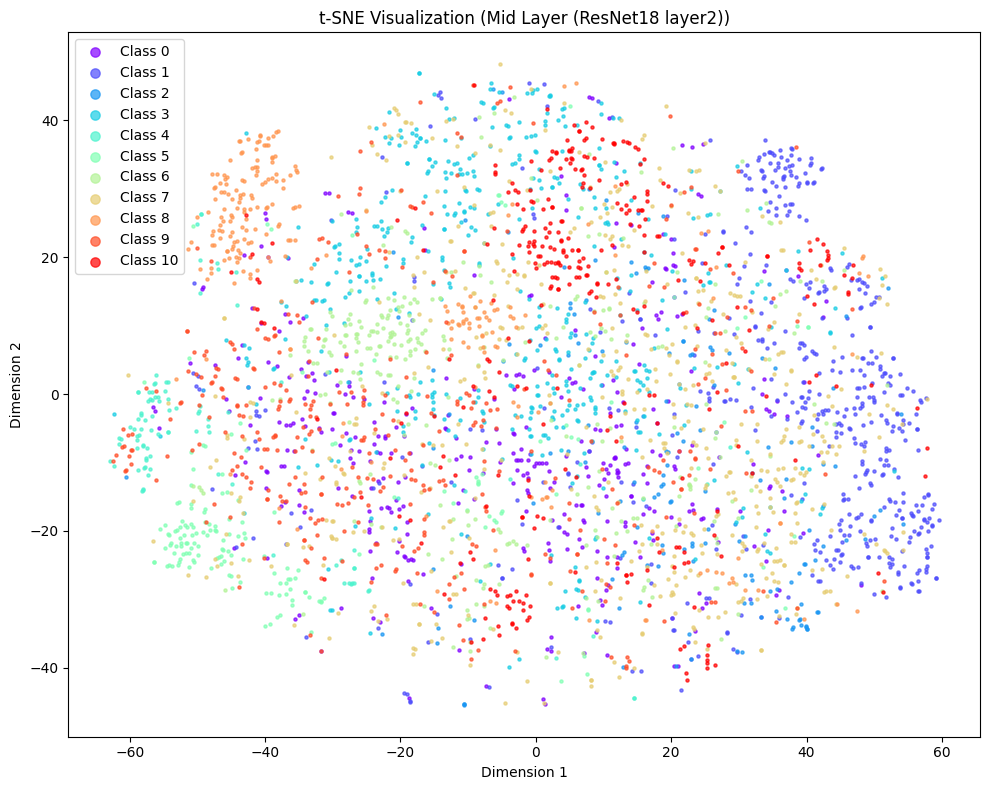

圖片已儲存：tsne_Mid_Layer_(ResNet18_layer2).png


Extracting [Top Layer (ResNet18 layer4)]:   0%|          | 0/57 [00:00<?, ?it/s]

[Top Layer (ResNet18 layer4)] feature 維度：(3643, 512)
[Top Layer (ResNet18 layer4)] 執行 t-SNE 中...


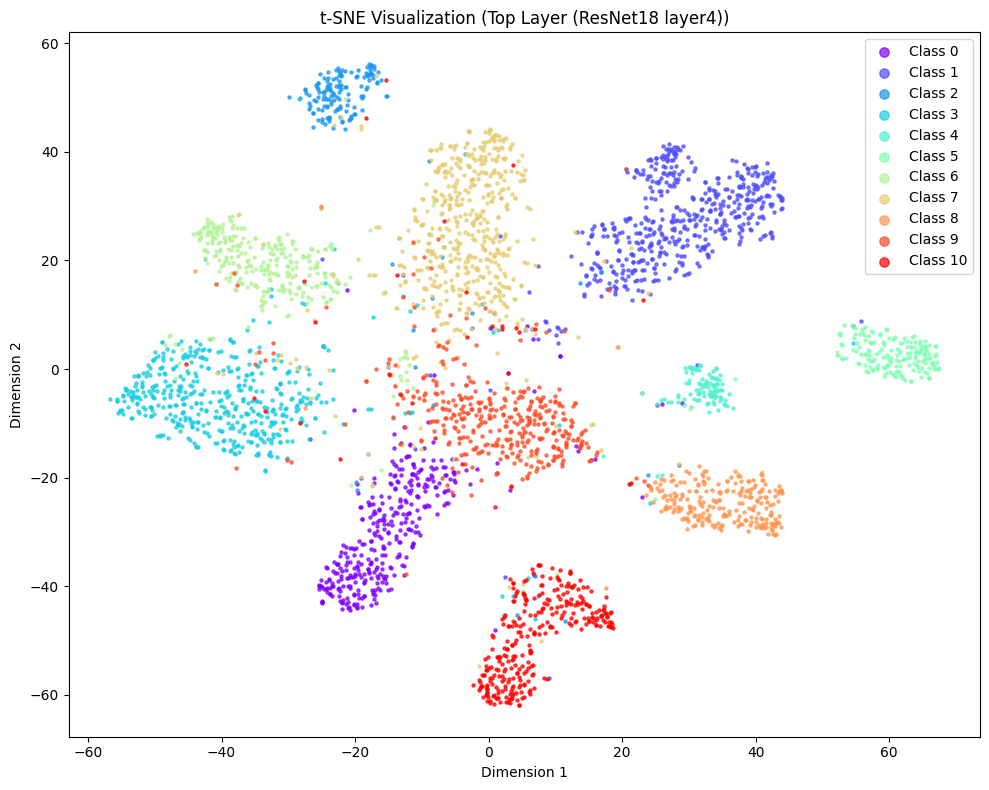

圖片已儲存：tsne_Top_Layer_(ResNet18_layer4).png


In [31]:
vis_valid_set    = FoodDataset(f"{DATA_DIR}/valid", tfm=test_tfm)
vis_valid_loader = DataLoader(vis_valid_set, batch_size=64,
                               shuffle=False, num_workers=2, pin_memory=True)

def visualize_tsne(model, loader, stage, title, device):
    features_list, labels_list = [], []
    for imgs, lbls in tqdm(loader, desc=f"Extracting [{title}]"):
        with torch.no_grad():
            feat = extract_features(model, imgs.to(device), stage)
            feat = F.adaptive_avg_pool2d(feat, 1).flatten(1)  # GAP → 向量
        features_list.extend(feat.cpu().numpy())
        labels_list.extend(lbls.numpy())

    features = np.array(features_list)
    labels   = np.array(labels_list)
    print(f"[{title}] feature 維度：{features.shape}")
    print(f"[{title}] 執行 t-SNE 中...")

    features_2d = TSNE(n_components=2, init='pca',
                       random_state=42, perplexity=30).fit_transform(features)

    plt.figure(figsize=(10, 8))
    colors = cm.rainbow(np.linspace(0, 1, 11))
    for label_id in np.unique(labels):
        mask = (labels == label_id)
        plt.scatter(features_2d[mask, 0], features_2d[mask, 1],
                    label=f"Class {label_id}", color=colors[label_id],
                    s=5, alpha=0.7)
    plt.legend(markerscale=3, loc='best')
    plt.title(f"t-SNE Visualization ({title})")
    plt.xlabel("Dimension 1"); plt.ylabel("Dimension 2")
    plt.tight_layout()
    fname = f"tsne_{title.replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"圖片已儲存：{fname}")

visualize_tsne(model_vis, vis_valid_loader, stage="mid",
               title="Mid Layer (ResNet18 layer2)", device=device)
visualize_tsne(model_vis, vis_valid_loader, stage="top",
               title="Top Layer (ResNet18 layer4)", device=device)